<a href="https://colab.research.google.com/github/gmauricio-toledo/NLP-LCC/blob/main/Notebooks/11-Transformers_Embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>BERT</h1>

En esta notebook exploraremos el uso de modelos tipo BERT para resolver la tarea de *Análisis de Sentimientos*. Esto lo haremos de dos formas:

1. Haciendo fine-tuning a un modelo BERT.
2. Usando los embeddings generados por BERT como features para un algoritmo de ML.

Usaremos modelos pre-entrenados almacenados en [HuggingFace](https://huggingface.co/).

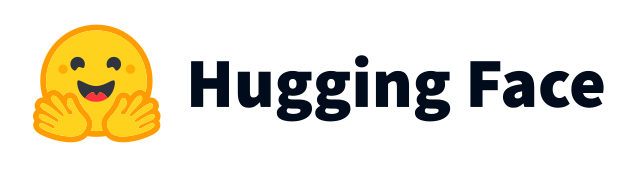

---

*Hugging Face, Inc. es una empresa estadounidense conocida por su biblioteca de transformadores creada para aplicaciones de procesamiento de lenguaje natural y su plataforma que permite a los usuarios compartir [datasets](https://huggingface.co/datasets) y [modelos](https://huggingface.co/models) de aprendizaje automático.  Su campo de acción principal es el NLP, pero también se centra en otras áreas del ML, como la visión de máquina, el aprendizaje por refuerzo y el aprendizaje supervisado.*

---

# 1. Dataset

In [1]:
!gdown 1PrXR-fo52VFWGLu1cBsKxSvtiUHXLtW0

Downloading...
From: https://drive.google.com/uc?id=1PrXR-fo52VFWGLu1cBsKxSvtiUHXLtW0
To: /content/AI_vs_Human_Detection_1K.csv
100% 159k/159k [00:00<00:00, 60.8MB/s]


In [16]:
!gdown 1bxwTomQY0q6iEf6zVejAy_M_Ra4Pavuu

Downloading...
From: https://drive.google.com/uc?id=1bxwTomQY0q6iEf6zVejAy_M_Ra4Pavuu
To: /content/RestMex2021-train.csv
100% 1.44M/1.44M [00:00<00:00, 92.9MB/s]


In [31]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv('RestMex2021-train.csv')
df.dropna(subset=['Opinion'], inplace=True)
df.reset_index(drop=True, inplace=True)
display(df)

y = df['Label']

X_train_raw, X_test_raw, y_train, y_test = train_test_split(df['Opinion'].values,
                                                            y,
                                                            test_size=0.2,
                                                            random_state=642,
                                                            stratify=y)
print(f"Training set size: {len(X_train_raw)}")
print(f"Test set size: {len(X_test_raw)}")

,Unnamed: 0,Title,Opinion,Place,Gender,Age,Country,Date,Label
0,0,"""No es para recomendarse""","""Las famosas momias de Guanajuato. El museo en...",Museo de las Momias,Male,48,México,02/07/2013,0
1,1,"""Es un mercado tradicional, no es nada del otr...","""Allí puedes encontrar comida o souvenirs. Es ...",Mercado Hidalgo,Male,52,México,06/09/2016,0
2,2,"""No visitar""","""Es tardado entrar al museo, una vez dentro no...",Museo de las Momias,Male,42,México,25/12/2017,0
3,3,"""No le veo atractivo. A ver semejantes cacharros""","""Entiendo que a muchos les cautive o llamé la ...",Museo de las Momias,Female,24,México,14/08/2013,0
4,4,"""Nada fuera de lo común""","""La fruta y verdura son poco frescos, al igual...",Mercado Hidalgo,Female,19,México,01/08/2017,0
...,...,...,...,...,...,...,...,...,...
4410,4412,"""Beautiful architecture""","""This university is famous because of its beau...",Universidad de Guanajuato,Male,24,México,21/04/2014,1
4411,4413,"""Imponente la universidad, TODO guanajuato es ...","""Lo que no me gusto fue la comida, pero es muy...",Universidad de Guanajuato,Female,44,México,05/07/2015,1
4412,4414,Lugar magico,Esta excelente para pasar a sentarse unos minu...,Jardín de la Unión,Male,-1,México,2018,1
4413,4415,"""¡Su fachada es hermosa!""","""No tuvimos la fortuna de entrar a verlo, ya q...",Teatro Juárez,Female,47,México,22/10/2012,1


Training set size: 3532
Test set size: 883


In [32]:
df[['Opinion','Label']]

,Opinion,Label
0,"""Las famosas momias de Guanajuato. El museo en...",0
1,"""Allí puedes encontrar comida o souvenirs. Es ...",0
2,"""Es tardado entrar al museo, una vez dentro no...",0
3,"""Entiendo que a muchos les cautive o llamé la ...",0
4,"""La fruta y verdura son poco frescos, al igual...",0
...,...,...
4410,"""This university is famous because of its beau...",1
4411,"""Lo que no me gusto fue la comida, pero es muy...",1
4412,Esta excelente para pasar a sentarse unos minu...,1
4413,"""No tuvimos la fortuna de entrar a verlo, ya q...",1


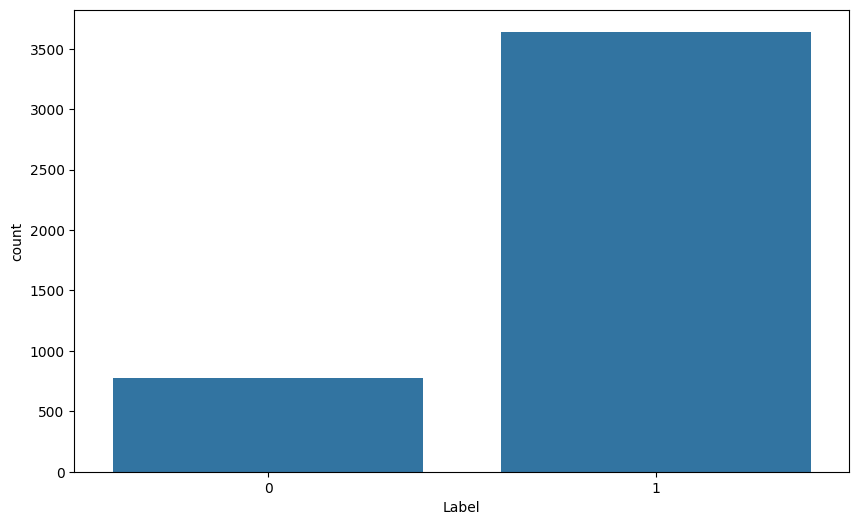

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(x='Label', data=df)
plt.show()

In [23]:
from imblearn.under_sampling import RandomUnderSampler

rus = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = rus.fit_resample(df[['Opinion']], df['Label'])


In [34]:
import numpy as np

random_idxs = np.random.choice(len(X_train_raw), size=4, replace=False)

for k in random_idxs:
    clase = [y_train[k]]
    print(f"Class:{clase}\n{X_train_raw[k]}")

Class:[np.int64(1)]
"Es algo extraño el saber que hay este tipo de sitios que tienen cosas así, pero bueno hay cosas para todo tipo de gustos…"
Class:[np.int64(1)]
"Adaptado a las nuevas necesidades de los alumnos, pero son dejar de lado su aspecto colonial, instalaciones muy cuidadas, sin duda un lugar al que no puedes dejar de ir si visitas Guanajuato."
Class:[np.int64(1)]
"Poder sentarte en las escaleras y disfrutar del paisaje es lo máximo,muy recomendable!si tienen la oportunidad no duden en visitarla."
Class:[np.int64(1)]
"Lo recomiendo como una de las principales atracciones, las momias estás perfectamente conservadas en sus aparadores, es interesante y te explican la historia de cada una, además afuera venden artesanías a muy buen precio, creo que muy económico lo recomiendo."


#2. Limpieza y preprocesamiento

En los modelos de lenguaje modernos como BERT y sus sucesores, el preprocesamiento tradicional del texto (como la eliminación de stopwords, lematización o stemming) ya no es necesario ni recomendable.

Estos modelos están diseñados para entender el contexto y la estructura del lenguaje tal como aparece en el texto crudo, incluyendo palabras funcionales que aportan significado contextual.

Sin embargo, sí es común limpiar el texto de artefactos no lingüísticos, como etiquetas HTML, códigos de escape, URLs, o caracteres especiales irrelevantes.

En su lugar, el preprocesamiento se limita generalmente a la tokenización mediante el tokenizador específico del modelo (por ejemplo, WordPiece para BERT), la adición de tokens especiales ([CLS], [SEP]), y el relleno o truncamiento de secuencias para ajustarlas a una longitud fija.

Conservar el texto original permite al modelo aprovechar al máximo su capacidad contextual y semántica.

In [35]:
import re
import html

def clean_text(text):
    # Decodificar entidades HTML
    text = html.unescape(text)
    # Eliminar etiquetas HTML
    text = re.sub(r'<[^>]+>', ' ', text)
    # Normalizar espacios
    text = re.sub(r'\s+', ' ', text).strip()
    # Quitar "
    text = re.sub(r'"', '', text)
    return text

In [36]:
train_docs = [clean_text(doc) for doc in X_train_raw]
test_docs = [clean_text(doc) for doc in X_test_raw]

In [37]:
for k in random_idxs:
    print(f"Review:\n{train_docs[k]}")

Review:
Es algo extraño el saber que hay este tipo de sitios que tienen cosas así, pero bueno hay cosas para todo tipo de gustos…
Review:
Adaptado a las nuevas necesidades de los alumnos, pero son dejar de lado su aspecto colonial, instalaciones muy cuidadas, sin duda un lugar al que no puedes dejar de ir si visitas Guanajuato.
Review:
Poder sentarte en las escaleras y disfrutar del paisaje es lo máximo,muy recomendable!si tienen la oportunidad no duden en visitarla.
Review:
Lo recomiendo como una de las principales atracciones, las momias estás perfectamente conservadas en sus aparadores, es interesante y te explican la historia de cada una, además afuera venden artesanías a muy buen precio, creo que muy económico lo recomiendo.


# Embeddings

El enfoque de embeddings pre-entrenados con MLP consiste en utilizar modelos de lenguaje entrenados en grandes corpus de texto para convertir documentos en vectores de características numéricas de alta dimensionalidad. Estos embeddings capturan relaciones semánticas y sintácticas del lenguaje que son difíciles de obtener con técnicas tradicionales como bag-of-words o TF-IDF. Una vez obtenidos los embeddings, se alimentan a una red neuronal multicapa que aprende a mapear estas representaciones vectoriales a las clases objetivo.

Este método separa la extracción de características del proceso de clasificación, permitiendo aprovechar el conocimiento lingüístico de modelos entrenados en millones de documentos mientras se mantiene la simplicidad de arquitecturas de clasificación tradicionales.

Usaremos dos modelos para generar los embeddings:

* BERT Base
* `all-MiniLM-L6-v2`

all-MiniLM-L6-v2 es un modelo de transformador compacto basado en la arquitectura MiniLM que genera embeddings de texto de 384 dimensiones. Fue entrenado mediante destilación de conocimiento a partir de modelos más grandes, manteniendo un rendimiento competitivo con solo 22 millones de parámetros. El modelo utiliza 6 capas de atención y está optimizado para tareas de recuperación de información y similitud semántica, procesando secuencias de hasta 512 tokens y produciendo representaciones vectoriales que capturan el significado contextual del texto de entrada.

In [ ]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
train_embeddings = model.encode(train_docs)
test_embeddings = model.encode(test_docs)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
print(f"Train embeddings shape: {train_embeddings.shape}")
print(f"Test embeddings shape: {test_embeddings.shape}")

Train embeddings shape: (2000, 384)
Test embeddings shape: (1000, 384)


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score

clfs = [
    RandomForestClassifier(),
    SVC(C=2),
    LogisticRegression(max_iter=10000)
]

names = [
    'Random Forest',
    'SVC',
    'Logistic Regression'
]

for name,clf in zip(names,clfs):
    clf.fit(train_embeddings, sample_train_labels)
    y_pred = clf.predict(test_embeddings)
    f1 = f1_score(sample_test_labels, y_pred)
    print(f"Clasificador: {name}\n\tF1-score: {round(f1,3)}")

Clasificador: Random Forest
	F1-score: 0.759
Clasificador: SVC
	F1-score: 0.801
Clasificador: Logistic Regression
	F1-score: 0.802
